In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"

In [2]:
import pandas as pd
from rdkit.Chem import PandasTools

df = pd.read_csv(DATA_PROCESSED / "egfr_clean.csv")
PandasTools.AddMoleculeColumnToFrame(df, smilesCol="Clean Smiles", molCol="RDkit Mol", includeFingerprints=True)

Add common descriptors to the Dataframe. These descriptors can help predict drug-likeness.

In [3]:
from rdkit.Chem import Descriptors, QED

desc_funcs = {
    "Molecular Weight": Descriptors.MolWt,
    "cLogP": Descriptors.MolLogP,
    "Polar Surface Area": Descriptors.TPSA,
    "Hydrogen Bond Donors": Descriptors.NumHDonors,
    "Hydrogen Bond Acceptors": Descriptors.NumHAcceptors,
    "Num Rotatable Bonds": Descriptors.NumRotatableBonds,
    "Heavy Atoms": Descriptors.HeavyAtomCount,
    "Aromatic Rings": Descriptors.NumAromaticRings,
    "QED": QED.qed,
}

for col, fun in desc_funcs.items():
    df[col] = df["RDkit Mol"].apply(fun)

In [4]:
df.columns

Index(['Clean InchiKey', 'Clean Smiles', 'Molecule ChEMBL ID', 'Acrylamide',
       'pChEMBL Median', 'pChEMBL std', 'Activity Measurements', 'RDkit Mol',
       'Molecular Weight', 'cLogP', 'Polar Surface Area',
       'Hydrogen Bond Donors', 'Hydrogen Bond Acceptors',
       'Num Rotatable Bonds', 'Heavy Atoms', 'Aromatic Rings', 'QED'],
      dtype='str')

Lipinski and Veber heuristics predict oral bioavailability, while the endpoint here
is biochemical binding affinity against an isolated kinase domain. There is no
mechanistic reason for the two to be linked; the distributions are shown to
characterise the chemical space of the dataset, not to predict potency.

In [5]:
# Lipinski, orally available molecules shouldn't exceed 2 violations
lipinski = {
    "MW > 500": df["Molecular Weight"] > 500,
    "cLogP > 5": df["cLogP"] > 5,
    "HBD > 5": df["Hydrogen Bond Donors"] > 5,
    "HBA > 10": df["Hydrogen Bond Acceptors"] > 10,
}

violations = pd.DataFrame(lipinski)
df["Lipinski Violations"] = violations.sum(axis=1)

counts = (df["Lipinski Violations"]
          .value_counts()
          .reindex(range(5), fill_value=0)
          .rename_axis("violations")
          .to_frame("compounds"))
counts["percent"] = 100 * counts["compounds"] / len(df)
counts = counts.style.format({"percent": "{:.1f}%"})
counts

,compounds,percent
violations,,
0,3485,51.9%
1,1925,28.7%
2,1246,18.6%
3,51,0.8%
4,2,0.0%


In [6]:
# Binding efficiiency per heavy atom
df["Ligand Efficiency"] = 1.37 * df["pChEMBL Median"] / df["Heavy Atoms"]

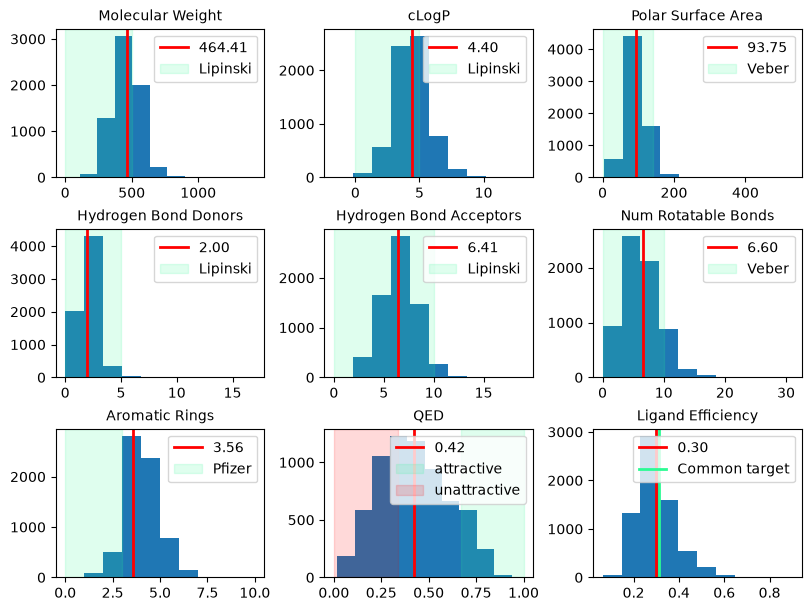

In [7]:
# Distributions of common chemical descriptors
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(3,3, layout='constrained', figsize=(8,6))
plot_cols = [c for c in desc_funcs if c != "Heavy Atoms"] + ["Ligand Efficiency"]

for ax, col in zip(axs.flatten(), plot_cols):
    data = df[col]
    ax.hist(data)
    ax.set_title(col, fontsize=10)

    mean_val = np.mean(data)
    ax.axvline(mean_val, color="red", linestyle="-", linewidth=2, label=f'{mean_val:.2f}')

    # Lipinski markers
    if col == "Molecular Weight":
        ax.axvspan(0, 500, color="#2bfb93", alpha=0.15, label="Lipinski")
    elif col == "cLogP":
        ax.axvspan(0, 5, color="#2bfb93", alpha=0.15, label="Lipinski")
    elif col == "Num Rotatable Bonds":
        ax.axvspan(0, 10, color="#2bfb93", alpha=0.15, label="Veber")
    elif col == "Hydrogen Bond Donors":
        ax.axvspan(0, 5, color="#2bfb93", alpha=0.15,  label="Lipinski")
    elif col == "Hydrogen Bond Acceptors":
        ax.axvspan(0, 10, color="#2bfb93", alpha=0.15,  label="Lipinski")
    elif col == "Polar Surface Area":
        ax.axvspan(0, 140, color="#2bfb93", alpha=0.15,  label="Veber")
    elif col == "Aromatic Rings":
        ax.axvspan(0, 3, color="#2bfb93", alpha=0.15, label="Pfizer")
    elif col == "QED":
        ax.axvspan(0.67, 1, color="#2bfb93", alpha=0.15, label="attractive")
        ax.axvspan(0, 0.34, color="red", alpha=0.15, label="unattractive")
    elif col == "Ligand Efficiency":
        ax.axvline(.31, color="#2bfb93", lw=2, label="Common target")

    ax.legend(fontsize=10)

plt.savefig(FIGURES / "molecular_descriptors.png", dpi=300)

### Descriptor distributions with drug-likeness reference ranges

Shaded regions mark the ranges associated with oral drug-likeness. These are
empirical heuristics derived from orally administered drugs, not physical
constraints. Many approved kinase inhibitors fall outside them.

**Lipinski's rule of five** (Lipinski et al., 1997) relates oral absorption to
four properties. Compounds violating two or more were found less likely to be
orally available:

| Property | Threshold |
|---|---|
| Molecular weight | ≤ 500 Da |
| cLogP | ≤ 5 |
| Hydrogen bond donors | ≤ 5 |
| Hydrogen bond acceptors | ≤ 10 |

**Veber's rules** (Veber et al., 2002) add two criteria from a larger dataset,
both covering molecular flexibility and polarity:

| Property | Threshold |
|---|---|
| Topological polar surface area | ≤ 140 Å² |
| Rotatable bonds | ≤ 10 |

**Ligand efficiency** measures binding affinity per heavy atom, allowing
compounds of different sizes to be compared on how efficiently they use their
atoms:

$$LE = 1.37 × \text{pChEMBL} / \text{heavy atom count}$$

in kcal/mol/heavy atom. The factor 1.37 converts a log10 potency to binding
free energy at room temperature. Values around 0.3 are typical for optimised
leads. LE is unreliable for very small molecules, where dividing by a small atom
count inflates the value.

**NOTE** Found a physically implausible outlier in the ligand efficiency data, because one of the rows has Smiles="[Zn+2]". 
This has been handled by adding a filter in the clean up notebook to ensure compounds are organic. Only 1 row was affected.

### Murcko-type decomposition of molecules into scaffolds

A Murcko scaffold consists of the ring systems and the linker between ring 
units. The side chains are removed from the scaffold. 
A small number of scaffolds account for the majority of drugs.

ref: Bemis, G. W.; Murcko, M. A. “The Properties of Known Drugs. 1. Molecular Frameworks.” J. Med. Chem. 39:2887-93 (1996).

In [8]:
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import Chem

def get_murcko_core(mol):
    core = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(core)

df["Murcko Scaffold"] = df["RDkit Mol"].apply(get_murcko_core)

In [9]:
top_scaffolds = df["Murcko Scaffold"].value_counts().reset_index(name="Count").sort_index()[:10]
PandasTools.AddMoleculeColumnToFrame(top_scaffolds, smilesCol="Murcko Scaffold", molCol="Scaffold Mol")

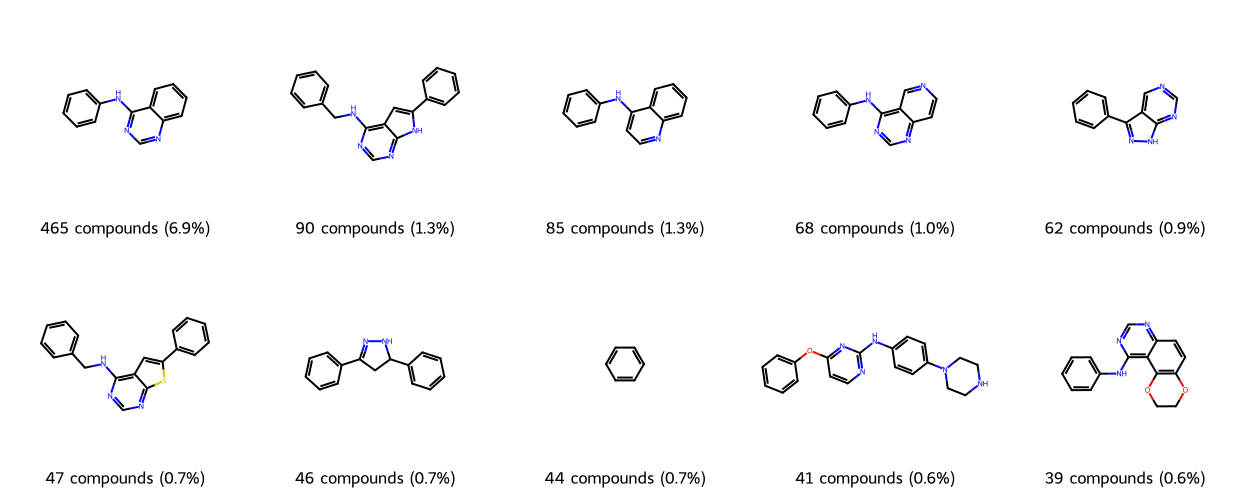

In [10]:
from rdkit.Chem import Draw

legends = [f"{n} compounds ({100*n/len(df):.1f}%)" for n in top_scaffolds["Count"]]
img = Draw.MolsToGridImage(top_scaffolds["Scaffold Mol"], molsPerRow=5, legends=legends, 
                            returnPNG=False, subImgSize=(250, 250))
img.save(FIGURES / "top_scaffolds.png")
img

In [11]:
df["Murcko Scaffold"].nunique()

2658

The top 10 Murcko scaffolds account for ~15% of the dataset, and there is a large number (2658 / 6709) of unique scaffolds. This implies a seemingly diverse chemistry within the dataset of EGFR binderes. However, some scaffolds are almost identical to each other, differing only by a carbon <-> nitrogen substitution on the ring. 
Notably, many of the scaffolds contain quinazoline-like moieties as found in the tyrosine kinase inhibitors gefitinib and erlotinib. 

Next, check if whether the potency of some scaffolds is systematically higher. 

In [12]:
# What are the average pChEMBL values WITHIN a Murcko scaffold?
df.groupby("Murcko Scaffold")["pChEMBL Median"].agg(["count", "median", "std"]).nlargest(10, "count")

,count,median,std
Murcko Scaffold,,,
c1ccc(Nc2ncnc3ccccc23)cc1,465,7.465,1.147927
c1ccc(CNc2ncnc3[nH]c(-c4ccccc4)cc23)cc1,90,8.430,1.053308
c1ccc(Nc2ccnc3ccccc23)cc1,85,6.030,1.253043
c1ccc(Nc2ncnc3ccncc23)cc1,68,8.055,1.121378
c1ccc(-c2n[nH]c3ncncc23)cc1,62,5.210,0.748197
c1ccc(CNc2ncnc3sc(-c4ccccc4)cc23)cc1,47,8.150,0.744962
c1ccc(C2=NNC(c3ccccc3)C2)cc1,46,5.030,0.561990
c1ccccc1,44,4.715,0.804050
c1ccc(Oc2ccnc(Nc3ccc(N4CCNCC4)cc3)n2)cc1,41,5.220,0.955975


So, the scaffold is a substantial predictor of potency. A ML model may appear to 
achieve good correlation, but is merely distinguishing chemotypes. A good ML 
model will make predictions which consider structure activity relationships as 
well. The real benchmark then becomes, can the model achieve good correlation 
*within* the scaffolds? 

Use SMARTS to make a more general classification. 
These should help determine a minimum benchmark for model evaluation.

True
False
True
True
False
False
False
False
False
True


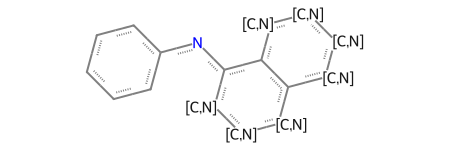

In [13]:
# Group 1 is 4-Anilinoquinazoline-like
label1 = "4-Anilinoquinazoline-like"
group1 = top_scaffolds["Scaffold Mol"].iloc[[0,2,3]].to_list()
pattern1 = Chem.MolFromSmarts("c1ccc(Nc2[c,n][c,n][c,n][cR2]3[c,n][c,n][c,n][c,n][cR2]23)cc1")

# Check the pattern over the scaffolds
for m in top_scaffolds["Scaffold Mol"]:
    print(m.HasSubstructMatch(pattern1))

pattern1

In [14]:
# Group 2 uses a SMARTS pattern, based on scaffold 6
label2 = "Aminopurine-like"
smiles2 = Chem.MolToSmiles(top_scaffolds["Scaffold Mol"].iloc[5])
smiles2

'c1ccc(CNc2ncnc3sc(-c4ccccc4)cc23)cc1'

False
True
False
False
False
True
False
False
False
False


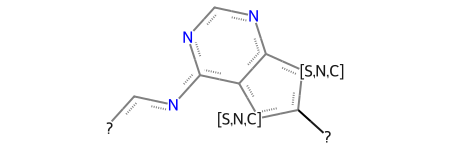

In [15]:
# Generalized group 2 by modifying the SMILES
pattern2 = Chem.MolFromSmarts('aCNc2ncnc3[s,n,c]c(-a)[s,n,c]c23')

# Check the pattern over the scaffolds
for m in top_scaffolds["Scaffold Mol"]:
    print(m.HasSubstructMatch(pattern2))
pattern2

In [16]:
# A third group is single aromatic rings, like pyridine and benzene
label3 = "Monocyclic"

In [17]:
df.columns

Index(['Clean InchiKey', 'Clean Smiles', 'Molecule ChEMBL ID', 'Acrylamide',
       'pChEMBL Median', 'pChEMBL std', 'Activity Measurements', 'RDkit Mol',
       'Molecular Weight', 'cLogP', 'Polar Surface Area',
       'Hydrogen Bond Donors', 'Hydrogen Bond Acceptors',
       'Num Rotatable Bonds', 'Heavy Atoms', 'Aromatic Rings', 'QED',
       'Lipinski Violations', 'Ligand Efficiency', 'Murcko Scaffold'],
      dtype='str')

There are then 4 groups of compounds: 4-Anilinoquinazoline-like, aminopurine-like, monocycles and the covalent binders.

In [18]:
def classify(row):
    mol = row["RDkit Mol"]
    if row["Acrylamide"]:
        return "Covalent"
    elif mol.HasSubstructMatch(pattern2):
        return label2
    elif mol.HasSubstructMatch(pattern1):
        return label1
    elif row["Aromatic Rings"] == 1:
        return label3
    else:
        return "Other"

df["Classification"] = df.apply(classify, axis=1)

In [19]:
groups = df.groupby("Classification")["pChEMBL Median"].agg(["count", "median", "std"])

groups

,count,median,std
Classification,,,
4-Anilinoquinazoline-like,1577,7.31,1.173611
Aminopurine-like,161,8.22,1.043962
Covalent,1838,7.07,1.273073
Monocyclic,64,5.08,1.010390
Other,3069,6.26,1.252052


In [20]:
print(groups.to_markdown())

| Classification            |   count |   median |     std |
|:--------------------------|--------:|---------:|--------:|
| 4-Anilinoquinazoline-like |    1577 |     7.31 | 1.17361 |
| Aminopurine-like          |     161 |     8.22 | 1.04396 |
| Covalent                  |    1838 |     7.07 | 1.27307 |
| Monocyclic                |      64 |     5.08 | 1.01039 |
| Other                     |    3069 |     6.26 | 1.25205 |


### Chemotype classification

Compounds were assigned to mutually exclusive classes using validated SMARTS
patterns. A compound with an acrylamide is classified as covalent regardless of 
its core, since the binding mechanism takes
priority over the scaffold.

The classes differ by over three log units in median potency, from the monocyclic
compounds at 5.09 to the aminopurine-like series at 8.22. Within-class spread is
consistently around 1.2 log units, so variation between classes exceeds variation
within them. Chemotype alone therefore carries substantial information about
potency in this dataset.

The monocyclic compounds are the weakest and smallest group, consistent with
these being fragment-like or weakly active screening hits rather than optimised 
inhibitors. The covalent compounds sit below the anilinoquinazolines despite 
including several approved drugs, which is expected: their reported IC50 values 
are time-dependent and do not represent equilibrium binding.
The "Other" column is a heterogeneous remainder.

### Fragment Analysis

Fingerprints tell which fragments are present in structures. They can be 
used to quantitatively measure molecular similarity. 

Further, we get another baseline for model evaluation by considering how 
fragments predict potency. To what extent does modelling a 3D structure by
Boltz-2 improve the prediction over simply knowing which fragments are present?

In [21]:
from rdkit.Chem import rdFingerprintGenerator
from rdkit import Chem, DataStructs
import numpy as np

# Random subset of 200 molecules
subset = np.random.choice(len(df), size=200, replace=False)

# Compute the fingerprints 
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps = [gen.GetFingerprint(m) for m in df["RDkit Mol"]]
sub = [fps[i] for i in subset]

# Use fingerprints to compute similarity
sim = np.array([DataStructs.BulkTanimotoSimilarity(f, sub) for f in sub])

c:\Users\lauren\miniconda3\envs\boltz\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\lauren\miniconda3\envs\boltz\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


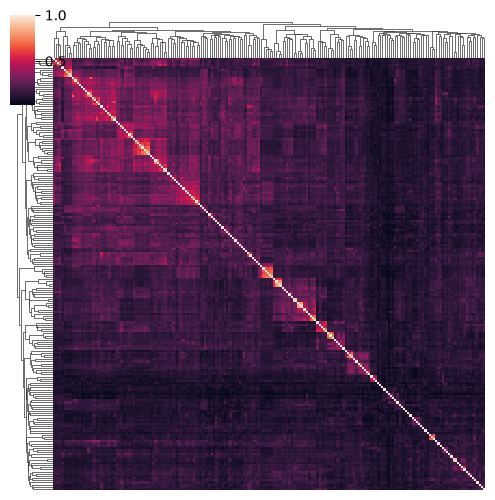

In [22]:
import seaborn

# Create heatmap
# Use hierarchical clustering, so similar molecules are near each other
hm = seaborn.clustermap(sim, xticklabels=False, yticklabels=False,
                    row_cluster=True, dendrogram_ratio=0.08, figsize=(5, 5))
hm.savefig(FIGURES / "tanimoto_similarity_sample_heat.png")

mean : 0.17
Half of all compound pairs have a Tanimoto similarity below 0.15, 90% fall below 0.28, and only the top 1% exceed 0.47.
There are just 7 near-duplicate pairs.


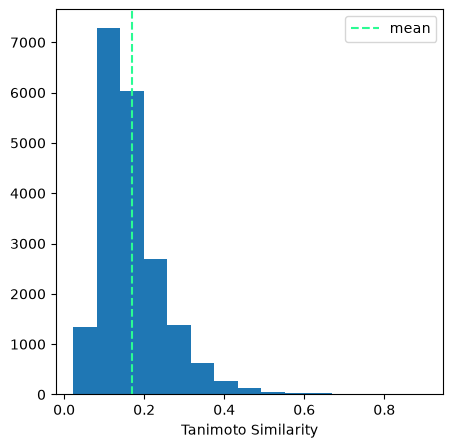

In [23]:
#  indices for the upper-triangle
tri = sim[np.triu_indices_from(sim, k=1)]
print(f"mean : {tri.mean():.2f}")
ps = np.percentile(tri, [50, 90, 99]).round(2)
print(f"Half of all compound pairs have a Tanimoto similarity below { ps[0] }, 90% fall below { ps[1] }, and only the top 1% exceed { ps[2] }.")
print(f"There are just {(tri > 0.80).sum()} near-duplicate pairs.")

fig, ax = plt.subplots(figsize=(5,5))
ax.hist(tri, bins=15)
ax.axvline(tri.mean(), label="mean", color="#2bfb93", ls="--")
ax.set_xlabel("Tanimoto Similarity")
ax.legend()

plt.savefig(FIGURES / "tanimoto_similarity_sample_dist.png")

The heatmap of Tanimoto similarities indicates some clusters of similarity, based on 
a random sample of 200 molecules. 

However, the mean pairwise Tanimoto is only 0.16. Half of all compound pairs have a Tanimoto 
similarity below 0.14, 90% fall below 0.25, and only the top 1% exceed 0.43.
There are just 4 near-duplicate pairs. The dataset is therefore chemically 
diverse rather than dominated by congeneric series.

As an exercise, I can still stratify my subset for Boltz-2 calculations across a
diverse set of finger prints (next notebook).

#### Principal component analysis over the finger prints
PCA on the fingerprints, colored by class and pChEMBL.

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(fps)
print(pca.explained_variance_ratio_.round(2), pca.explained_variance_ratio_.sum().round(2))

[0.07 0.04] 0.11


The variance explained by the first two principal components is very low, with a
sum near 11%. This is primarily due to the nature of the input data which is 
sparse and high dimensional. 

A plot of PC1 vs PC2 is shown for demonstrative purposes, but is limited in how
informative it may be.

In [25]:
# Label data points using marker shape
df["Classification"].unique()

markers = {'4-Anilinoquinazoline-like' : "o",
            'Other' : "*",
            'Covalent' : "v",  
            'Monocyclic' : "X",
            'Aminopurine-like' : "P",
          }

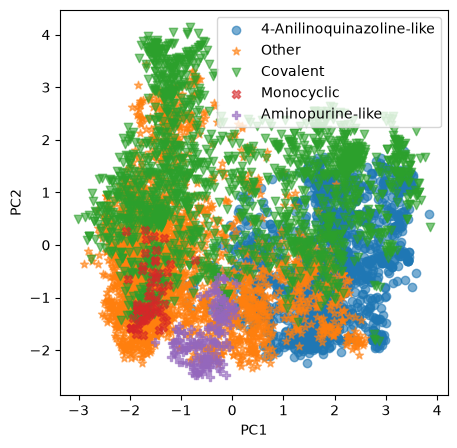

In [26]:
# Plot the first 2 principal components
fig, ax = plt.subplots(figsize=(5,5))

for c, m in markers.items():
    ind = df["Classification"] == c
    ax.scatter(coords[ind,0], coords[ind,1], label=c, marker=m, alpha=0.6)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()

plt.savefig(FIGURES / "PCA_fingerprints_pred_class.png")

Clustering is not apparent when plotting all the data and PC1 and PC2, but 
clusters emerge when the molecules are labeled by their "Classification".
This indicates the fingerprint space is somewhat aligned to the SMARTS 
classification. Unsurprisingly, this clustering applies least of all to the 
"Covalent" and the "Other" classes, which make minimal or no specification on 
the substructures. This observation passes a sanity check, but is based on some
circular reasoning. 

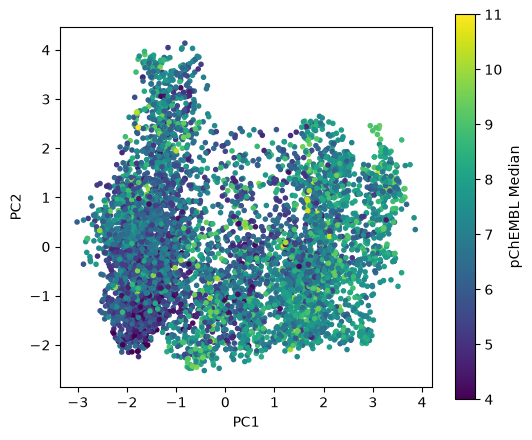

In [27]:
# Plot the first 2 principal components, color by the pChEMBL
import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(6,5))

norm = mcolors.Normalize(vmin=df["pChEMBL Median"].min(), vmax=df["pChEMBL Median"].max())

scat = ax.scatter(coords[:,0], coords[:,1], c=df["pChEMBL Median"], norm=norm, 
            marker=".", cmap="viridis")
cbar = fig.colorbar(scat, ax=ax)
cbar.set_label('pChEMBL Median')

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_aspect('equal')

plt.savefig(FIGURES / "PCA_fingerprints_pred_activity.png")

There is some visible clustering on the activity for the first two principal
components. In particular, the region in the lower left predicts low activity 
and corresponds to the "Monocycle" and "Other" classes. Essentially, the 
variance captured in the first 2 PCs very roughly separates high and moderate 
activity binders from low activity binders.

In [28]:
# exclude Mols column and write to file
cols = [c for c in df.columns if c != "RDkit Mol"]
df.to_csv(DATA_PROCESSED / "egfr_clean_classified.csv", columns=cols, index=False)